In [1]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Common import *
from Rollout import *
from ModelControl import *

In [2]:
N = 12000
M = 4000
N_test = 4000
data_range = [2,6,jnp.pi,12,20]
X_train, Y_train, axis_names = collect_data(N, data_range)
X_basis = select_basis_centres(X_train, M)
X_test, Y_test, axis_names = collect_data(N_test, data_range)

1749691899
1749692512


In [3]:
save_jnp_array("data_C1/X_train", X_train)
save_jnp_array("data_C1/Y_train", Y_train)
save_jnp_array("data_C1/X_basis", X_basis)
save_jnp_array("data_C1/X_test", X_test)
save_jnp_array("data_C1/Y_test", Y_test)

In [4]:
X_train = load_jnp_array("data_C1/X_train")
Y_train = load_jnp_array("data_C1/Y_train")
X_basis = load_jnp_array("data_C1/X_basis")
X_test = load_jnp_array("data_C1/X_test")
Y_test = load_jnp_array("data_C1/Y_test")

In [5]:
sigma_list = []
lam_list = []
alpha_list = []

for j in jnp.arange(jnp.shape(Y_train)[1]):
    sigma_j, lam_j, alpha_j, _ = fit_hyperparameters(X_train, Y_train[:, j], X_basis, X_test, Y_test[:, j])
    sigma_list.append(sigma_j)
    lam_list.append([lam_j])  # keep shape (1,)
    alpha_list.append(alpha_j)

sigma = jnp.vstack(sigma_list)
lam = jnp.array(lam_list)
alpha = jnp.stack(alpha_list, axis=1)

KeyboardInterrupt: 

In [14]:
save_jnp_array("data_C1/sigma", sigma)
save_jnp_array("data_C1/lam", lam)
save_jnp_array("data_C1/alpha", alpha)

In [8]:
sigma = load_jnp_array("data_C1/sigma")
lam = load_jnp_array("data_C1/lam")
alpha = load_jnp_array("data_C1/alpha")

In [9]:
print(lam)

[[1.4046286e-01]
 [1.0000000e-06]
 [1.1703834e-01]
 [1.7636977e-01]]


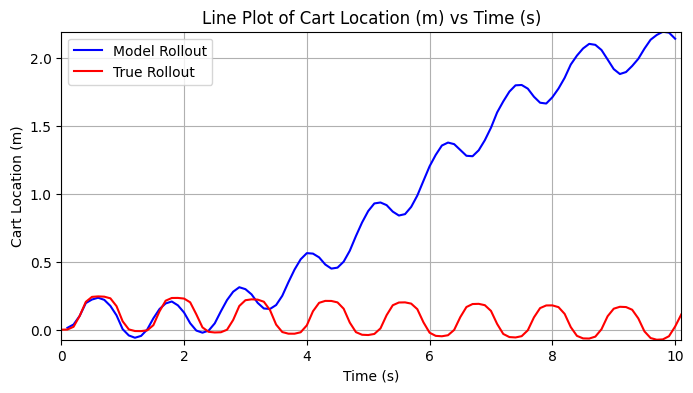

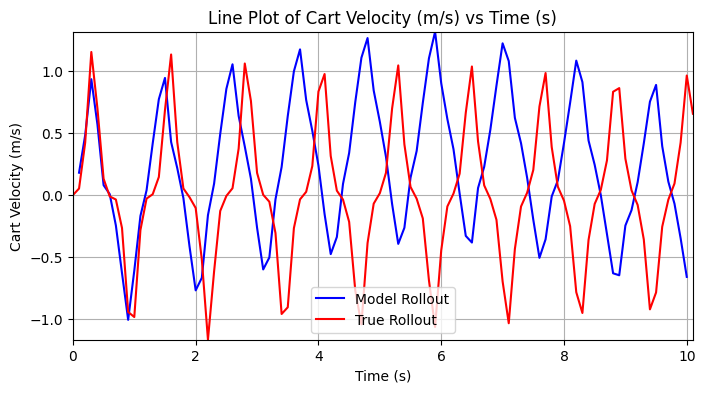

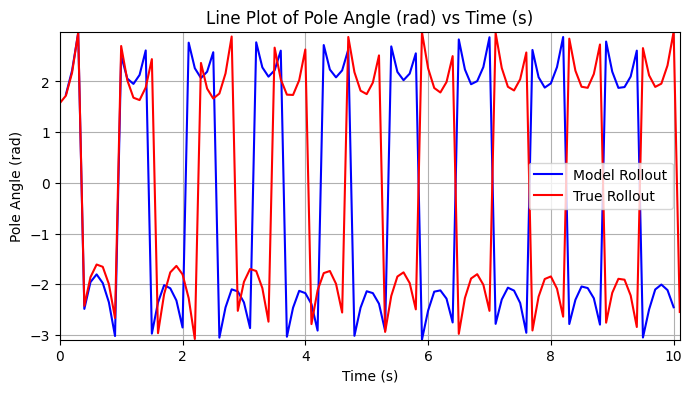

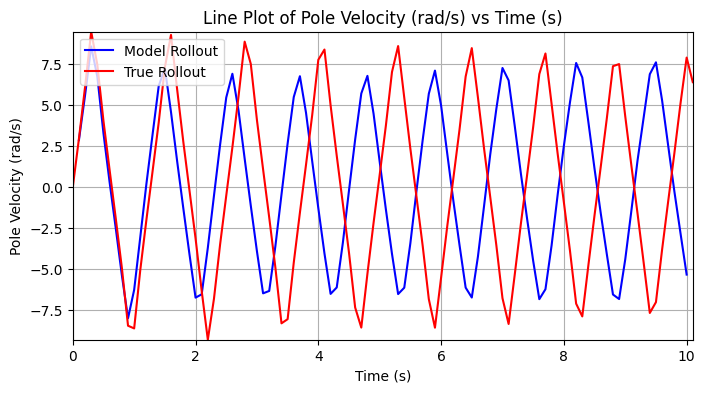

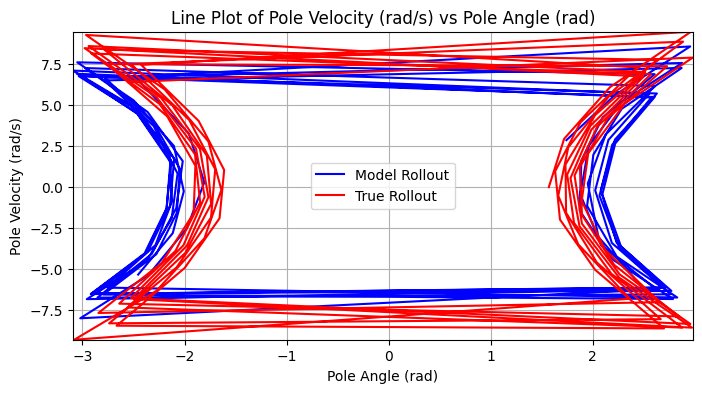

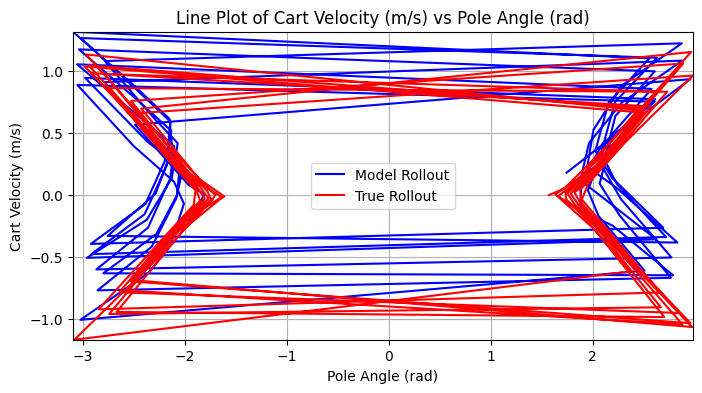

In [15]:
initial_state = [0.0, 0.0, np.pi/2, 0.0]
action = 0.0

state_array = non_linear_rollout(initial_state, action, X_basis, alpha, sigma, 10)
true_state_array, _ = rollout_action(initial_state, action, 10)

axis_names_1 = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)', 'Force (N)', 'Time (s)']
plot_model_graph(state_array, true_state_array, -1, 0, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 1, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 1, axis_names_1)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>